# Import Data

In [1]:
import pandas as pd
import numpy as np

In [2]:
import re

def extract_drive_id(url):
    """
    Hàm nhận vào URL Google Drive và trả về File ID
    Hỗ trợ cả dạng /file/d/ và open?id=
    """
    patterns = [
        r"https://drive\.google\.com/file/d/([a-zA-Z0-9_-]+)",  # dạng /file/d/ID
        r"id=([a-zA-Z0-9_-]+)"                                  # dạng ?id=ID
    ]

    for pattern in patterns:
        match = re.search(pattern, url)
        if match:
            return match.group(1)
    return None

# Sử dụng
url = "https://drive.google.com/open?id=1VAfzj4JjUVmY0Cy7BHDhmQnxqf93EI0XZvPGe1rmfPM&usp=drive_copy"
file_id = extract_drive_id(url)

if file_id:
    print("🎯 File ID extracted:", file_id)
else:
    print("❌ Không tìm thấy file ID từ link.")

# Bạn có thể dùng luôn với gdown:
import gdown
gdown.download(f"https://drive.google.com/uc?id={file_id}", "du_lieu_vong_2.xlsx", quiet=False)


🎯 File ID extracted: 1VAfzj4JjUVmY0Cy7BHDhmQnxqf93EI0XZvPGe1rmfPM


Downloading...
From (original): https://drive.google.com/uc?id=1VAfzj4JjUVmY0Cy7BHDhmQnxqf93EI0XZvPGe1rmfPM
From (redirected): https://docs.google.com/spreadsheets/d/1VAfzj4JjUVmY0Cy7BHDhmQnxqf93EI0XZvPGe1rmfPM/export?format=xlsx
To: /content/du_lieu_vong_2.xlsx
2.14MB [00:00, 12.5MB/s]


'du_lieu_vong_2.xlsx'

In [3]:
import pandas as pd

# Đường dẫn đến file (nếu đã tải về Colab)
file_path = "du_lieu_vong_2.xlsx"

# Đọc từng sheet
balance_sheet = pd.read_excel(file_path, sheet_name='1. Balance Sheet')
income_statement = pd.read_excel(file_path, sheet_name='2. Income Statement')
cash_flow = pd.read_excel(file_path, sheet_name='3. Cash Flow')

In [4]:
balance_sheet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8010 entries, 0 to 8009
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Công ty                                8010 non-null   int64  
 1   Năm                                    8010 non-null   int64  
 2   A. TÀI SẢN NGẮN HẠN                    8007 non-null   float64
 3   I. Tiền và các khoản tương đương tiền  8005 non-null   float64
 4   II. Đầu tư tài chính ngắn hạn          7988 non-null   float64
 5   III. Các khoản phải thu ngắn hạn       8001 non-null   float64
 6   IV. Hàng tồn kho                       8000 non-null   float64
 7   V. Tài sản ngắn hạn khác               7989 non-null   float64
 8   B. TÀI SẢN DÀI HẠN                     8005 non-null   float64
 9   I. Các khoản phải thu dài hạn          5677 non-null   float64
 10  II. Tài sản cố định                    5690 non-null   float64
 11  III.

In [5]:
income_statement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8010 entries, 0 to 8009
Data columns (total 18 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Công ty                                        8010 non-null   int64  
 1   Năm                                            8010 non-null   int64  
 2   Doanh thu bán hàng & cung cấp dịch vụ          8002 non-null   float64
 3   Các khoản giảm trừ doanh thu                   8002 non-null   float64
 4   Doanh thu thuần bán hàng và cung cấp dịch vụ   8002 non-null   float64
 5   Giá vốn hàng bán                               8002 non-null   float64
 6   Lợi nhuận gộp về bán hàng và cung cấp dịch vụ  8003 non-null   float64
 7   Doanh thu hoạt động tài chính                  8003 non-null   float64
 8   Chi phí tài chính                              8003 non-null   float64
 9   - Trong đó: Chi phí lãi vay                    8004 

In [6]:
cash_flow.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8010 entries, 0 to 8009
Data columns (total 6 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Công ty                                        8010 non-null   int64  
 1   Năm                                            8010 non-null   int64  
 2   Lưu Chuyển Tiền Thuần Từ Hoạt Động Kinh Doanh  7718 non-null   float64
 3   Lưu Chuyển Tiền Thuần Từ Hoạt Động Đầu Tư      7718 non-null   float64
 4   Lưu Chuyển Tiền Thuần Từ Hoạt Động Tài Chính   7718 non-null   float64
 5   Lưu Chuyển Tiền Thuần Trong Kỳ                 7718 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 375.6 KB


In [7]:
# Thực hiện join 3 bảng theo 'Công ty' và 'Năm'
df = balance_sheet.merge(income_statement, on=['Công ty', 'Năm'], how='outer') \
                      .merge(cash_flow, on=['Công ty', 'Năm'], how='outer')

# Hiển thị kết quả
df

,Công ty,Năm,A. TÀI SẢN NGẮN HẠN,I. Tiền và các khoản tương đương tiền,II. Đầu tư tài chính ngắn hạn,III. Các khoản phải thu ngắn hạn,IV. Hàng tồn kho,V. Tài sản ngắn hạn khác,B. TÀI SẢN DÀI HẠN,I. Các khoản phải thu dài hạn,...,Chi phí quản lý doanh nghiệp,Lợi nhuận thuần từ hoạt động kinh doanh,Thu nhập khác,Chi phí khác,Lợi nhuận/(lỗ) khác,Tổng lợi nhuận kế toán trước thuế,Lưu Chuyển Tiền Thuần Từ Hoạt Động Kinh Doanh,Lưu Chuyển Tiền Thuần Từ Hoạt Động Đầu Tư,Lưu Chuyển Tiền Thuần Từ Hoạt Động Tài Chính,Lưu Chuyển Tiền Thuần Trong Kỳ
0,1,2019,1.646746e+09,1.856268e+07,0.0,0.0,8.937737e+08,7.344099e+08,0.000000e+00,NaN,...,-6.009983e+08,1.063467e+08,0.0,0.0,0.0,1.063467e+08,NaN,NaN,NaN,NaN
1,1,2020,1.646746e+09,1.856268e+07,0.0,0.0,8.937737e+08,7.344099e+08,0.000000e+00,NaN,...,-6.009983e+08,1.063467e+08,0.0,0.0,0.0,1.063467e+08,NaN,NaN,NaN,NaN
2,1,2021,2.270616e+09,1.443187e+08,0.0,0.0,1.006335e+09,1.119962e+09,0.000000e+00,NaN,...,-9.022598e+08,-9.436094e+07,75000000.0,0.0,75000000.0,-1.936094e+07,6.850536e+07,0.0,0.000000e+00,6.850536e+07
3,1,2022,2.746170e+09,1.514191e+08,0.0,0.0,1.495783e+09,1.098968e+09,0.000000e+00,NaN,...,-1.299517e+09,-3.936219e+08,255000000.0,0.0,255000000.0,-1.386219e+08,1.514191e+08,0.0,0.000000e+00,1.514191e+08
4,1,2023,3.565011e+09,5.213576e+07,0.0,0.0,2.415631e+09,1.097244e+09,0.000000e+00,NaN,...,-1.187554e+09,-3.855762e+07,110000000.0,-13000000.0,97000000.0,5.844238e+07,-9.928337e+07,0.0,0.000000e+00,-9.928337e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8005,1602,2019,1.571950e+09,4.868998e+07,0.0,76835347.0,1.390557e+09,5.586803e+07,1.280538e+09,0.0,...,-3.131161e+09,-9.196464e+08,0.0,-131312401.0,-131312401.0,-1.050959e+09,-4.267060e+07,0.0,0.000000e+00,-4.267060e+07
8006,1602,2020,2.941837e+09,5.432543e+08,0.0,858396725.0,1.540186e+09,0.000000e+00,1.293345e+09,0.0,...,-4.737246e+09,-8.352104e+08,0.0,-50000.0,-50000.0,-8.352604e+08,6.945643e+08,-200000000.0,0.000000e+00,4.945643e+08
8007,1602,2021,8.223801e+08,2.310678e+08,0.0,50000000.0,4.840971e+08,5.721526e+07,1.166393e+09,0.0,...,-5.535484e+09,-2.947850e+09,3.0,-60625363.0,-60625360.0,-3.008475e+09,-3.121865e+08,0.0,0.000000e+00,-3.121865e+08
8008,1602,2022,1.615709e+09,1.286634e+09,0.0,156030200.0,1.229200e+08,5.012563e+07,9.964344e+08,0.0,...,-8.913970e+09,2.089103e+09,0.0,-95409906.0,-95409906.0,1.993693e+09,-8.395251e+08,-104909091.0,2.000000e+09,1.055566e+09


# So sánh tổng quan

In [8]:
df['GIAI_DOAN'] = df['Năm'].apply(
    lambda x: 'Trước COVID' if x == 2019 else ('COVID' if x in [2020, 2021] else 'Hậu COVID')
)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8010 entries, 0 to 8009
Data columns (total 40 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Công ty                                        8010 non-null   int64  
 1   Năm                                            8010 non-null   int64  
 2   A. TÀI SẢN NGẮN HẠN                            8007 non-null   float64
 3   I. Tiền và các khoản tương đương tiền          8005 non-null   float64
 4   II. Đầu tư tài chính ngắn hạn                  7988 non-null   float64
 5   III. Các khoản phải thu ngắn hạn               8001 non-null   float64
 6   IV. Hàng tồn kho                               8000 non-null   float64
 7   V. Tài sản ngắn hạn khác                       7989 non-null   float64
 8   B. TÀI SẢN DÀI HẠN                             8005 non-null   float64
 9   I. Các khoản phải thu dài hạn                  5677 

In [10]:
cols = [
    'Doanh thu thuần bán hàng và cung cấp dịch vụ',
    'Lợi nhuận thuần từ hoạt động kinh doanh',
    'Giá vốn hàng bán',
    'Chi phí bán hàng',
    'Chi phí quản lý doanh nghiệp',
    'Chi phí tài chính',
    'Chi phí khác',
    'Tổng lợi nhuận kế toán trước thuế'

    ]


In [11]:
mean_stats = df.groupby('GIAI_DOAN')[cols].mean().round(2)
print(mean_stats)


             Doanh thu thuần bán hàng và cung cấp dịch vụ  \
GIAI_DOAN                                                   
COVID                                        1.395395e+10   
Hậu COVID                                    2.142384e+10   
Trước COVID                                  1.885702e+10   

             Lợi nhuận thuần từ hoạt động kinh doanh  Giá vốn hàng bán  \
GIAI_DOAN                                                                
COVID                                  -1.645822e+09     -1.070386e+10   
Hậu COVID                              -2.815900e+07     -1.491889e+10   
Trước COVID                            -2.907097e+08     -1.298123e+10   

             Chi phí bán hàng  Chi phí quản lý doanh nghiệp  \
GIAI_DOAN                                                     
COVID           -2.641334e+09                 -1.947547e+09   
Hậu COVID       -3.588926e+09                 -2.492633e+09   
Trước COVID     -3.552042e+09                 -2.396115e+09   

       

In [12]:
# Tính trung bình doanh thu, lợi nhuận cho từng giai đoạn
giai_doan_avg = df.groupby('GIAI_DOAN')[
    ['Doanh thu thuần bán hàng và cung cấp dịch vụ', 'Lợi nhuận thuần từ hoạt động kinh doanh']
].mean()

# Tính % tăng trưởng từng chỉ số qua các giai đoạn
growth_rev = (
    (giai_doan_avg.loc['Hậu COVID', 'Doanh thu thuần bán hàng và cung cấp dịch vụ'] - giai_doan_avg.loc['COVID', 'Doanh thu thuần bán hàng và cung cấp dịch vụ'])
    / giai_doan_avg.loc['COVID', 'Doanh thu thuần bán hàng và cung cấp dịch vụ'] * 100
)
growth_profit = (
    (giai_doan_avg.loc['Hậu COVID', 'Lợi nhuận thuần từ hoạt động kinh doanh'] - giai_doan_avg.loc['COVID', 'Lợi nhuận thuần từ hoạt động kinh doanh'])
    / giai_doan_avg.loc['COVID', 'Lợi nhuận thuần từ hoạt động kinh doanh'] * 100
)
print(f"Tăng trưởng doanh thu trung bình hậu COVID: {growth_rev:.2f}%")
print(f"Tăng trưởng lợi nhuận trung bình hậu COVID: {growth_profit:.2f}%")


Tăng trưởng doanh thu trung bình hậu COVID: 53.53%
Tăng trưởng lợi nhuận trung bình hậu COVID: -98.29%


In [13]:
# Identify companies with any missing values in 'Doanh thu thuần bán hàng và cung cấp dịch vụ'
companies_with_null_revenue = df[df['Doanh thu thuần bán hàng và cung cấp dịch vụ'].isnull()]['Công ty'].unique()

# Filter out companies that have at least one null revenue value across all years
df = df[~df['Công ty'].isin(companies_with_null_revenue)].copy()

# Display information after filtering
print("Thông tin dataframe sau khi lọc chỉ giữ lại các công ty có doanh thu đầy đủ qua các năm:")
df.info()

Thông tin dataframe sau khi lọc chỉ giữ lại các công ty có doanh thu đầy đủ qua các năm:
<class 'pandas.core.frame.DataFrame'>
Index: 7970 entries, 0 to 8009
Data columns (total 40 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Công ty                                        7970 non-null   int64  
 1   Năm                                            7970 non-null   int64  
 2   A. TÀI SẢN NGẮN HẠN                            7967 non-null   float64
 3   I. Tiền và các khoản tương đương tiền          7965 non-null   float64
 4   II. Đầu tư tài chính ngắn hạn                  7948 non-null   float64
 5   III. Các khoản phải thu ngắn hạn               7961 non-null   float64
 6   IV. Hàng tồn kho                               7960 non-null   float64
 7   V. Tài sản ngắn hạn khác                       7949 non-null   float64
 8   B. TÀI SẢN DÀI HẠN                          

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Tính tổng doanh thu và tổng lợi nhuận từng năm toàn ngành
df_year = df.groupby('Năm').agg({
    'Doanh thu thuần bán hàng và cung cấp dịch vụ': 'sum',
    'Lợi nhuận thuần từ hoạt động kinh doanh': 'sum',

}).reset_index()

# Tính tăng trưởng năm sau so với năm trước
df_year['Tăng trưởng doanh thu (%)'] = df_year['Doanh thu thuần bán hàng và cung cấp dịch vụ'].pct_change() * 100
df_year['Tăng trưởng lợi nhuận (%)'] = df_year['Lợi nhuận thuần từ hoạt động kinh doanh'].pct_change() * 100


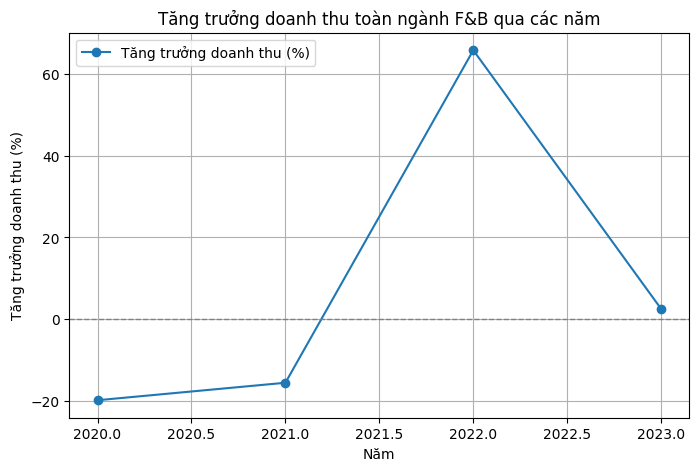

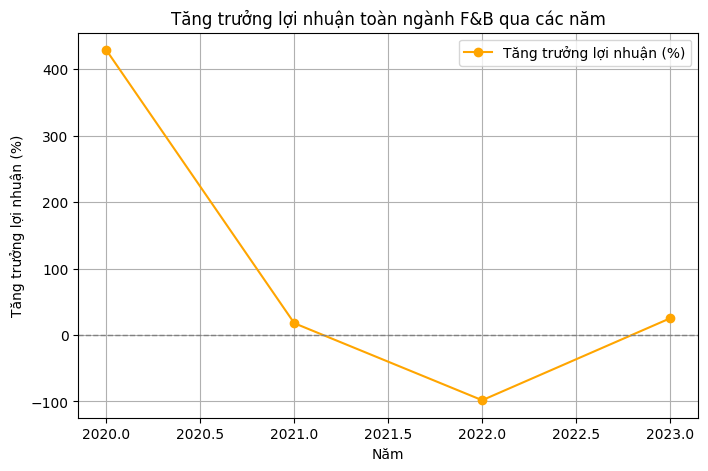

In [15]:
# Đồ thị tăng trưởng doanh thu qua các năm
plt.figure(figsize=(8,5))
plt.plot(df_year['Năm'], df_year['Tăng trưởng doanh thu (%)'], marker='o', label='Tăng trưởng doanh thu (%)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Tăng trưởng doanh thu toàn ngành F&B qua các năm')
plt.xlabel('Năm')
plt.ylabel('Tăng trưởng doanh thu (%)')
plt.legend()
plt.grid(True)
plt.show()

# Đồ thị tăng trưởng lợi nhuận qua các năm
plt.figure(figsize=(8,5))
plt.plot(df_year['Năm'], df_year['Tăng trưởng lợi nhuận (%)'], marker='o', color='orange', label='Tăng trưởng lợi nhuận (%)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Tăng trưởng lợi nhuận toàn ngành F&B qua các năm')
plt.xlabel('Năm')
plt.ylabel('Tăng trưởng lợi nhuận (%)')
plt.legend()
plt.grid(True)
plt.show()


# Nhóm công ty theo trung bình quy mô (chia theo trung bình doanh thu)


In [16]:
# Identify companies with any missing values in 'Doanh thu thuần bán hàng và cung cấp dịch vụ'
companies_with_null_revenue = df[df['Doanh thu thuần bán hàng và cung cấp dịch vụ'].isnull()]['Công ty'].unique()

# Filter out companies that have at least one null revenue value across all years
df = df[~df['Công ty'].isin(companies_with_null_revenue)].copy()

# Display information after filtering
print("Thông tin dataframe sau khi lọc chỉ giữ lại các công ty có doanh thu đầy đủ qua các năm:")
df.info()

Thông tin dataframe sau khi lọc chỉ giữ lại các công ty có doanh thu đầy đủ qua các năm:
<class 'pandas.core.frame.DataFrame'>
Index: 7970 entries, 0 to 8009
Data columns (total 40 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Công ty                                        7970 non-null   int64  
 1   Năm                                            7970 non-null   int64  
 2   A. TÀI SẢN NGẮN HẠN                            7967 non-null   float64
 3   I. Tiền và các khoản tương đương tiền          7965 non-null   float64
 4   II. Đầu tư tài chính ngắn hạn                  7948 non-null   float64
 5   III. Các khoản phải thu ngắn hạn               7961 non-null   float64
 6   IV. Hàng tồn kho                               7960 non-null   float64
 7   V. Tài sản ngắn hạn khác                       7949 non-null   float64
 8   B. TÀI SẢN DÀI HẠN                          

In [17]:
# Tính trung bình tổng tài sản theo công ty
avg_revenue = (
    df.dropna(subset=["Doanh thu bán hàng & cung cấp dịch vụ"])  # bỏ các dòng không có tổng tài sản
    .groupby("Công ty")["Doanh thu bán hàng & cung cấp dịch vụ"]
    .mean()
    .reset_index()
    .rename(columns={"Doanh thu bán hàng & cung cấp dịch vụ": "Doanh thu trung bình"})
)

# Gán loại hình quy mô
def classify_enterprise_scale(revenue):
    if revenue < 3e9:
        return 'Siêu nhỏ'
    elif revenue < 50e9:
        return 'Nhỏ'
    elif revenue < 300e9:
        return 'Vừa'
    else:
        return 'Lớn'

# Giả sử cột doanh thu của bạn là 'Doanh thu bán hàng & cung cấp dịch vụ'
avg_revenue['QUY MÔ DOANH NGHIỆP'] = avg_revenue['Doanh thu trung bình'].apply(classify_enterprise_scale)

In [18]:
# Gộp thông tin trung bình và quy mô doanh nghiệp vào df gốc
df = df.merge(avg_revenue, on="Công ty", how="left")

<ipython-input-19-62746f80e050>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=scale_counts.index, y=scale_counts.values, palette="Set2")


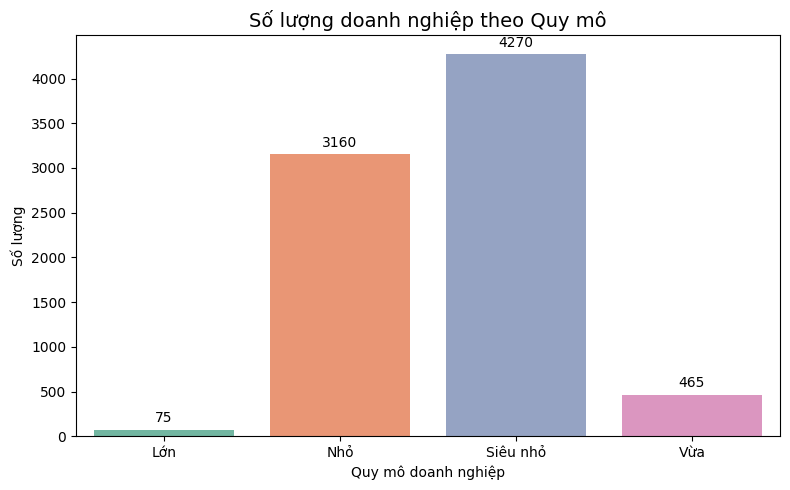

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Đếm số lượng doanh nghiệp theo quy mô
scale_counts = df["QUY MÔ DOANH NGHIỆP"].value_counts().sort_index()

# Vẽ biểu đồ cột với nhãn giá trị
plt.figure(figsize=(8, 5))
bars = sns.barplot(x=scale_counts.index, y=scale_counts.values, palette="Set2")

# Thêm nhãn giá trị lên từng cột
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f"{int(height)}", xy=(bar.get_x() + bar.get_width() / 2, height),
                  xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=10)

plt.title("Số lượng doanh nghiệp theo Quy mô", fontsize=14)
plt.xlabel("Quy mô doanh nghiệp")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()


# Correlation

In [20]:
df.isna().sum()

,0
Công ty,0
Năm,0
A. TÀI SẢN NGẮN HẠN,3
I. Tiền và các khoản tương đương tiền,5
II. Đầu tư tài chính ngắn hạn,22
III. Các khoản phải thu ngắn hạn,9
IV. Hàng tồn kho,10
V. Tài sản ngắn hạn khác,21
B. TÀI SẢN DÀI HẠN,5
I. Các khoản phải thu dài hạn,2317


In [21]:
df['Chi phí tài chính - Không tính lãi vay'] = df['Chi phí tài chính'] - df['- Trong đó: Chi phí lãi vay']

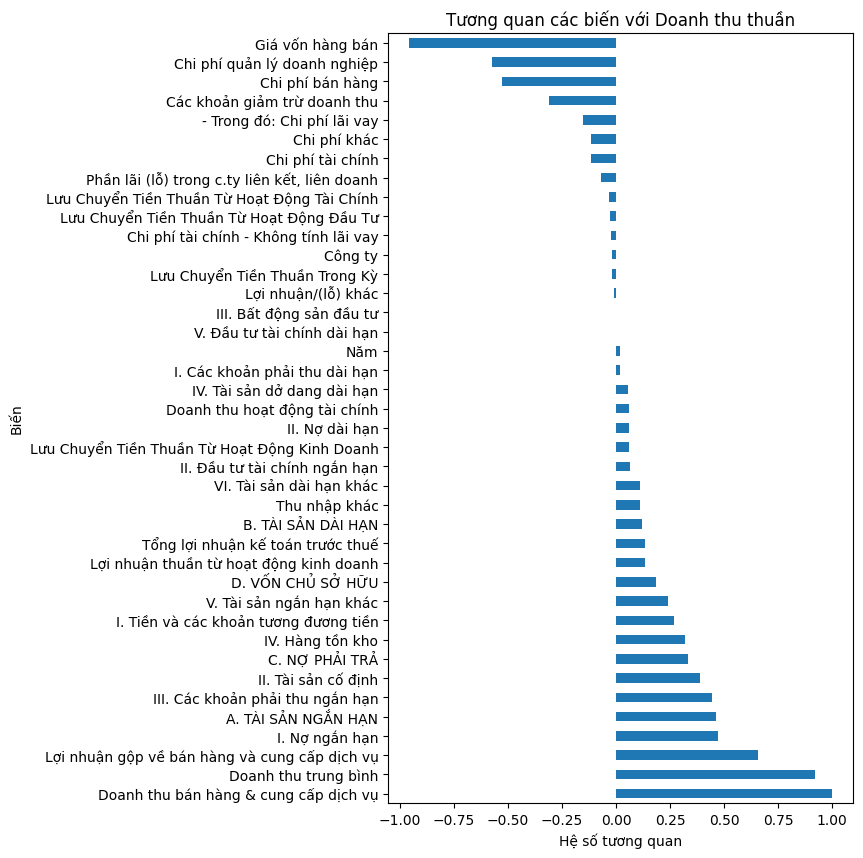

In [22]:
import matplotlib.pyplot as plt
# Select only numeric columns
df_numeric = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
corr_matrix = df_numeric.corr()

# Tương quan với doanh thu thuần
corr_with_rev = corr_matrix['Doanh thu thuần bán hàng và cung cấp dịch vụ'].drop('Doanh thu thuần bán hàng và cung cấp dịch vụ')
corr_with_rev.sort_values(ascending=False).plot(kind='barh', figsize=(6,10))
plt.title('Tương quan các biến với Doanh thu thuần')
plt.xlabel('Hệ số tương quan') # Use xlabel for horizontal bar chart
plt.ylabel('Biến') # Label the y-axis with the variable names
plt.show()

In [23]:
corr_with_rev.sort_values(ascending=False)

,Doanh thu thuần bán hàng và cung cấp dịch vụ
Doanh thu bán hàng & cung cấp dịch vụ,0.999855
Doanh thu trung bình,0.919028
Lợi nhuận gộp về bán hàng và cung cấp dịch vụ,0.656907
I. Nợ ngắn hạn,0.474286
A. TÀI SẢN NGẮN HẠN,0.465104
III. Các khoản phải thu ngắn hạn,0.444914
II. Tài sản cố định,0.391081
C. NỢ PHẢI TRẢ,0.335039
IV. Hàng tồn kho,0.320810
I. Tiền và các khoản tương đương tiền,0.270591


In [24]:
df['GIAI_DOAN'] = df['Năm'].map(
    lambda x: 'Trước COVID' if x == 2019 else
              'Trong COVID' if x in [2020, 2021] else
              'Hậu COVID'
)


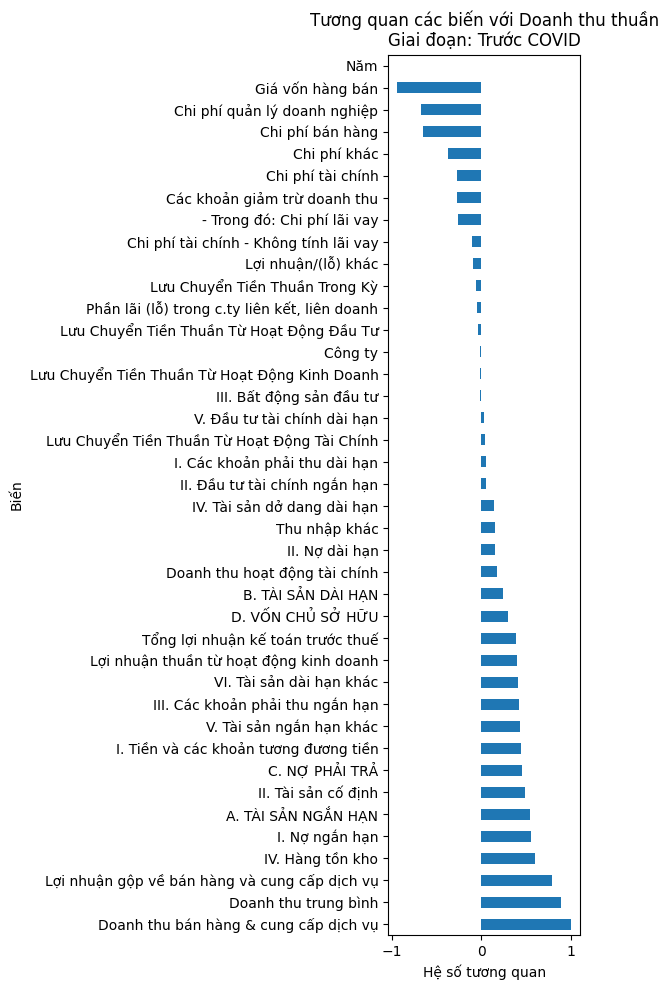

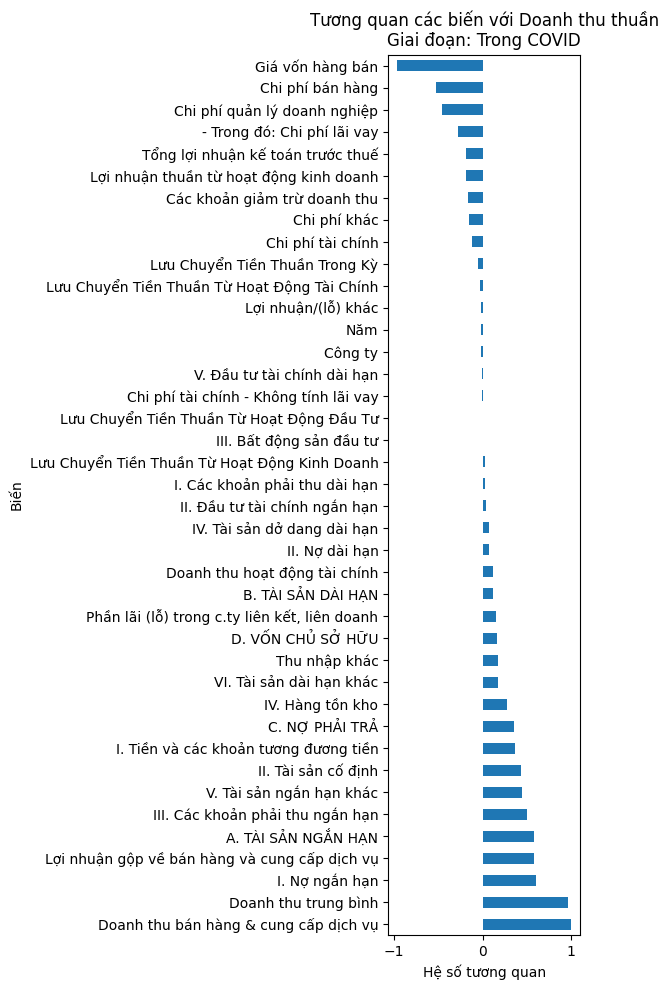

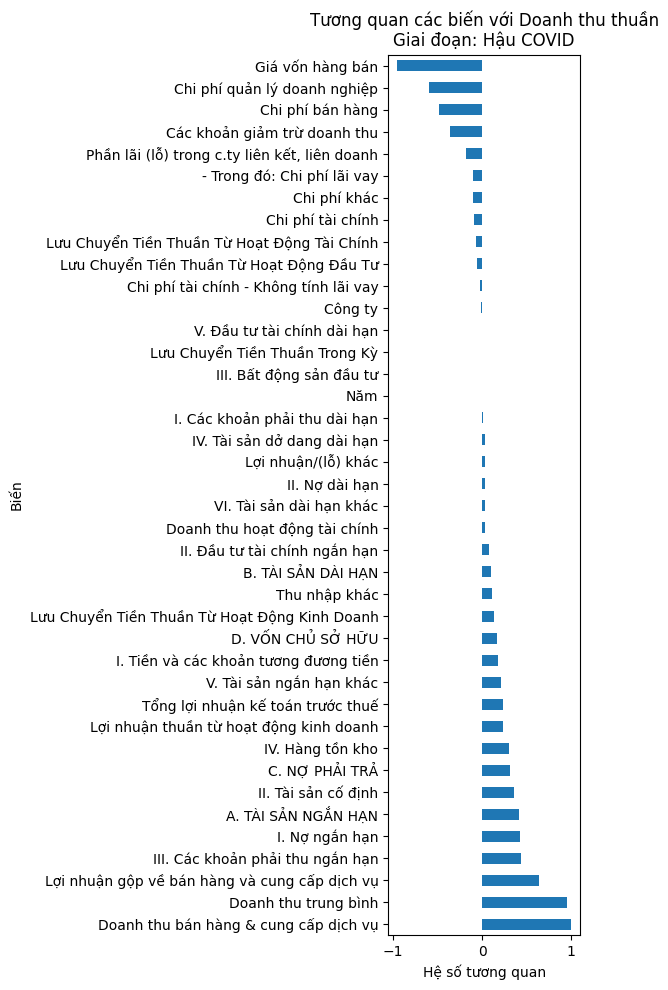

In [25]:
import matplotlib.pyplot as plt
import numpy as np

for giai_doan in ['Trước COVID', 'Trong COVID', 'Hậu COVID']:
    df_gd = df[df['GIAI_DOAN'] == giai_doan]
    df_numeric = df_gd.select_dtypes(include=np.number)
    corr_matrix = df_numeric.corr()
    if 'Doanh thu thuần bán hàng và cung cấp dịch vụ' in corr_matrix.columns:
        corr_with_rev = corr_matrix['Doanh thu thuần bán hàng và cung cấp dịch vụ'].drop('Doanh thu thuần bán hàng và cung cấp dịch vụ')
        corr_with_rev = corr_with_rev.sort_values(ascending=False)
        plt.figure(figsize=(6, 10))
        corr_with_rev.plot(kind='barh')
        plt.title(f'Tương quan các biến với Doanh thu thuần\nGiai đoạn: {giai_doan}')
        plt.xlabel('Hệ số tương quan')
        plt.ylabel('Biến')
        plt.tight_layout()
        plt.show()


## CORR theo giai đoạn

In [26]:
for giai_doan in ['Trước COVID', 'Trong COVID', 'Hậu COVID']:
    df_gd = df[df['GIAI_DOAN'] == giai_doan]
    df_numeric = df_gd.select_dtypes(include=np.number)
    corr_matrix = df_numeric.corr()
    if 'Doanh thu thuần bán hàng và cung cấp dịch vụ' in corr_matrix.columns:
        corr_with_rev = corr_matrix['Doanh thu thuần bán hàng và cung cấp dịch vụ'].drop('Doanh thu thuần bán hàng và cung cấp dịch vụ')
        corr_with_rev = corr_with_rev.sort_values(ascending=False)
        print(giai_doan)
        print(corr_with_rev)

Trước COVID
Doanh thu bán hàng & cung cấp dịch vụ            0.999844
Doanh thu trung bình                             0.883406
Lợi nhuận gộp về bán hàng và cung cấp dịch vụ    0.781650
IV. Hàng tồn kho                                 0.594629
I. Nợ ngắn hạn                                   0.547685
A. TÀI SẢN NGẮN HẠN                              0.536913
II. Tài sản cố định                              0.480558
C. NỢ PHẢI TRẢ                                   0.449285
I. Tiền và các khoản tương đương tiền            0.436017
V. Tài sản ngắn hạn khác                         0.433805
III. Các khoản phải thu ngắn hạn                 0.418781
VI. Tài sản dài hạn khác                         0.409177
Lợi nhuận thuần từ hoạt động kinh doanh          0.399143
Tổng lợi nhuận kế toán trước thuế                0.380454
D. VỐN CHỦ SỞ HỮU                                0.294377
B. TÀI SẢN DÀI HẠN                               0.238445
Doanh thu hoạt động tài chính                    0.167282
II

## CORR theo quy mô

In [27]:
import pandas as pd
import numpy as np

# Lấy danh sách các quy mô doanh nghiệp
quy_mos = df['QUY MÔ DOANH NGHIỆP'].dropna().unique()

for quy_mo in quy_mos:
    df_sub = df[df['QUY MÔ DOANH NGHIỆP'] == quy_mo]
    if len(df_sub) < 3:
        continue
    df_numeric = df_sub.select_dtypes(include=np.number)
    corr_matrix = df_numeric.corr()
    if 'Doanh thu thuần bán hàng và cung cấp dịch vụ' in corr_matrix.columns:
        corr_with_rev = corr_matrix['Doanh thu thuần bán hàng và cung cấp dịch vụ'].drop('Doanh thu thuần bán hàng và cung cấp dịch vụ')
        print(f"\n{str(quy_mo).upper()}")
        print('-' * len(str(quy_mo)))
        for var, corr in corr_with_rev.sort_values(ascending=False).items():
            print(f"{var}: {corr:.3f}")



NHỎ
---
Doanh thu bán hàng & cung cấp dịch vụ: 0.999
Doanh thu trung bình: 0.731
Lợi nhuận gộp về bán hàng và cung cấp dịch vụ: 0.594
I. Nợ ngắn hạn: 0.224
II. Tài sản cố định: 0.213
C. NỢ PHẢI TRẢ: 0.212
A. TÀI SẢN NGẮN HẠN: 0.209
II. Đầu tư tài chính ngắn hạn: 0.198
B. TÀI SẢN DÀI HẠN: 0.171
VI. Tài sản dài hạn khác: 0.156
IV. Hàng tồn kho: 0.148
II. Nợ dài hạn: 0.138
V. Đầu tư tài chính dài hạn: 0.122
Doanh thu hoạt động tài chính: 0.117
D. VỐN CHỦ SỞ HỮU: 0.116
III. Các khoản phải thu ngắn hạn: 0.111
I. Tiền và các khoản tương đương tiền: 0.089
I. Các khoản phải thu dài hạn: 0.083
Năm: 0.078
V. Tài sản ngắn hạn khác: 0.067
Thu nhập khác: 0.055
Lưu Chuyển Tiền Thuần Từ Hoạt Động Kinh Doanh: 0.048
IV. Tài sản dở dang dài hạn: 0.036
Phần lãi (lỗ) trong c.ty liên kết, liên doanh: 0.023
Lợi nhuận/(lỗ) khác: 0.013
III. Bất động sản đầu tư: 0.011
Lưu Chuyển Tiền Thuần Trong Kỳ: 0.001
Công ty: -0.001
Lưu Chuyển Tiền Thuần Từ Hoạt Động Tài Chính: -0.026
Lưu Chuyển Tiền Thuần Từ Hoạt Động Đ

## CORR theo quy mô và giai đoạn

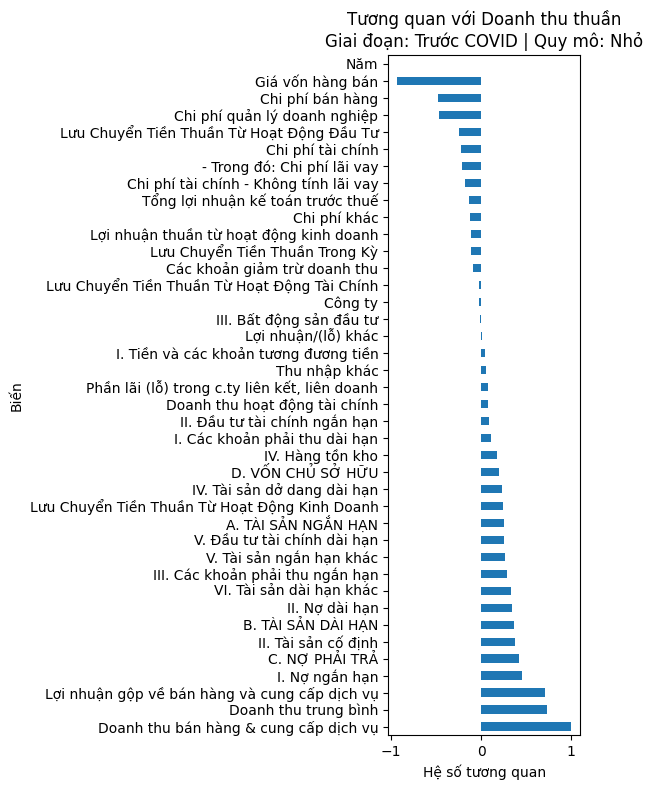

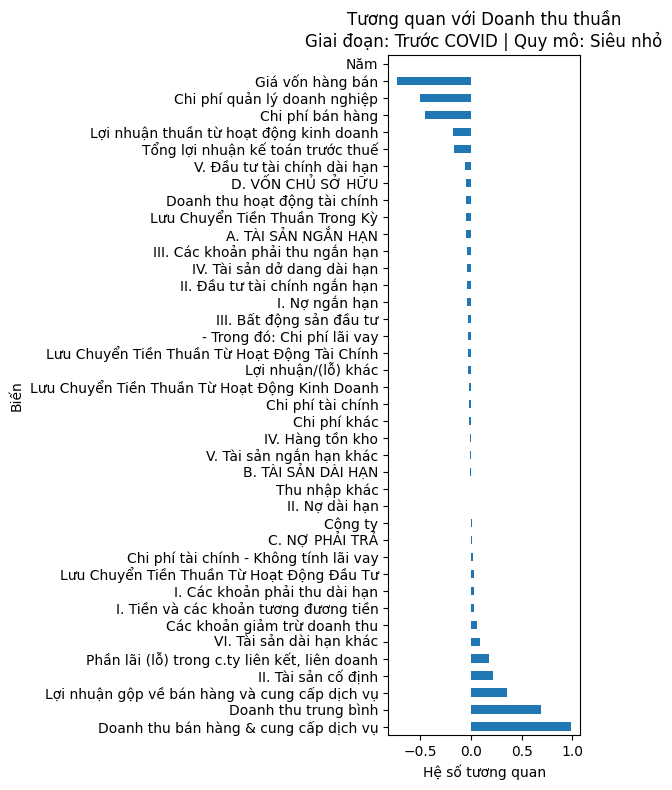

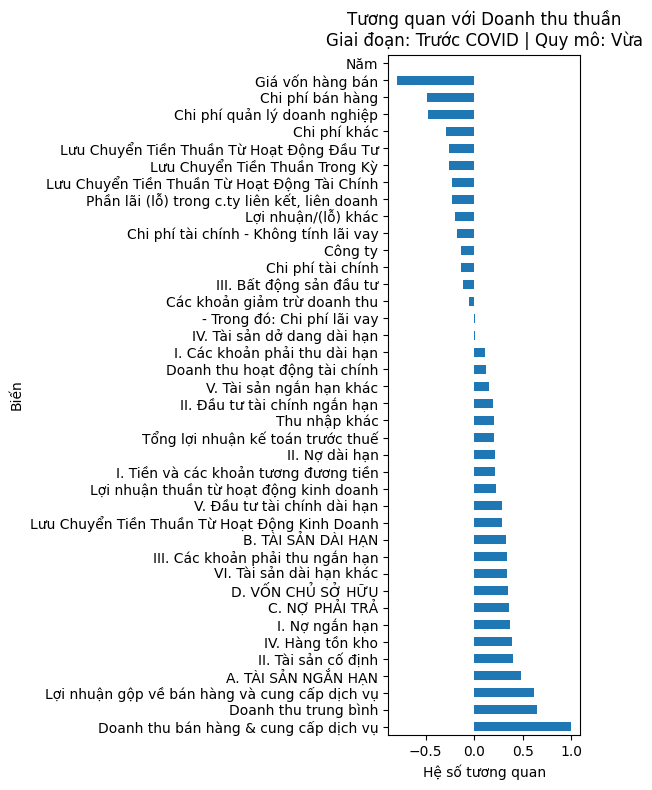

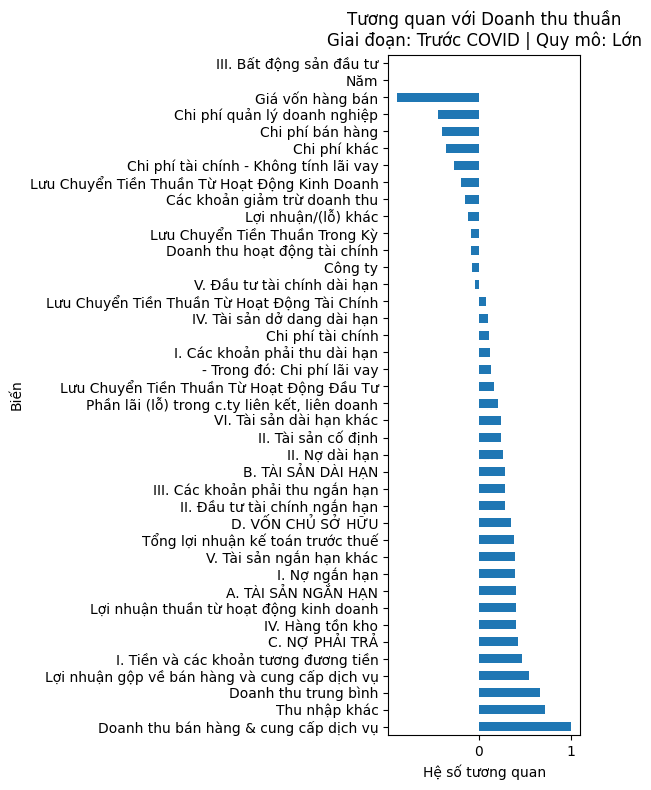

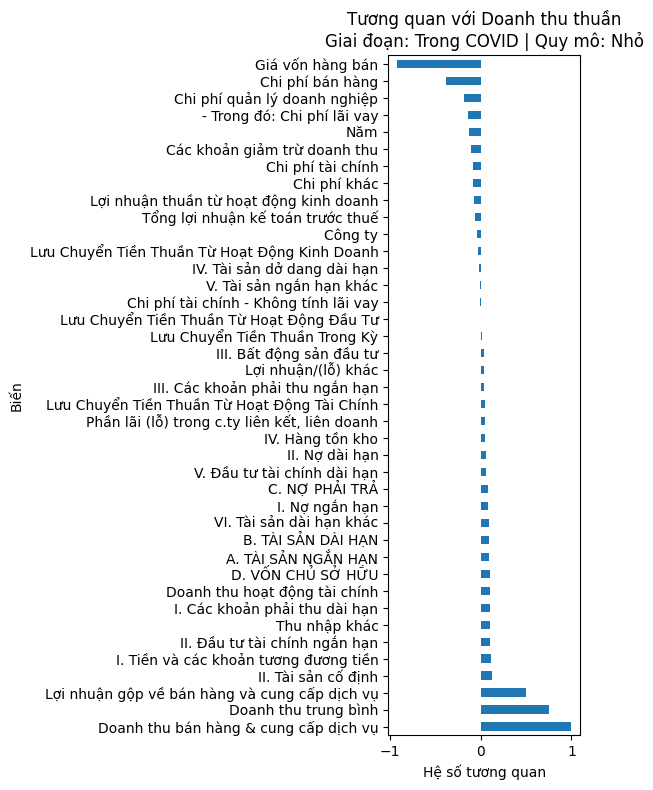

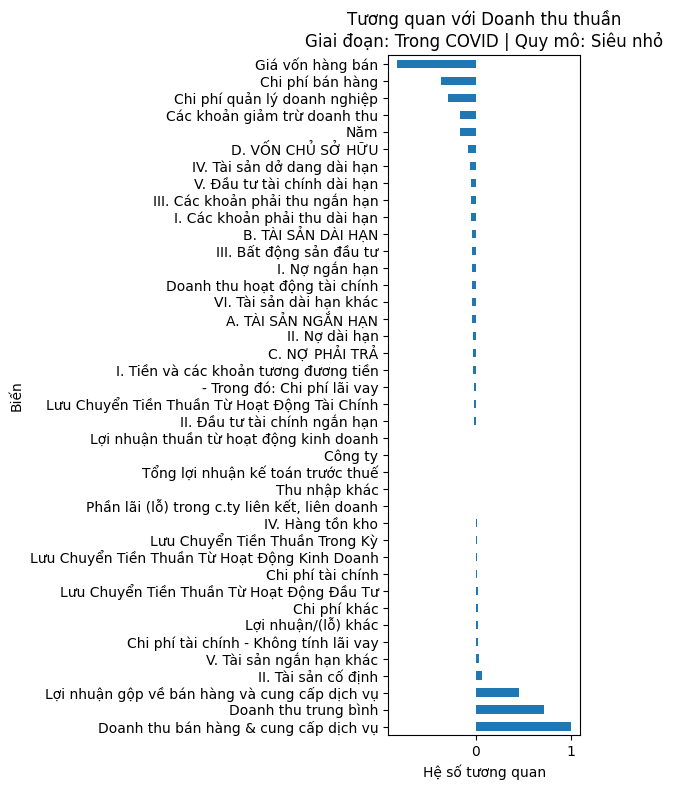

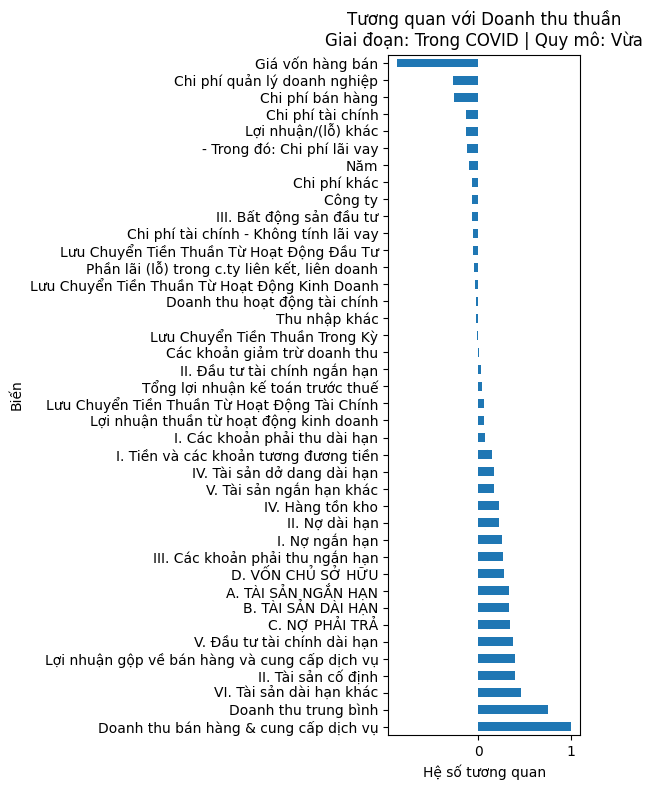

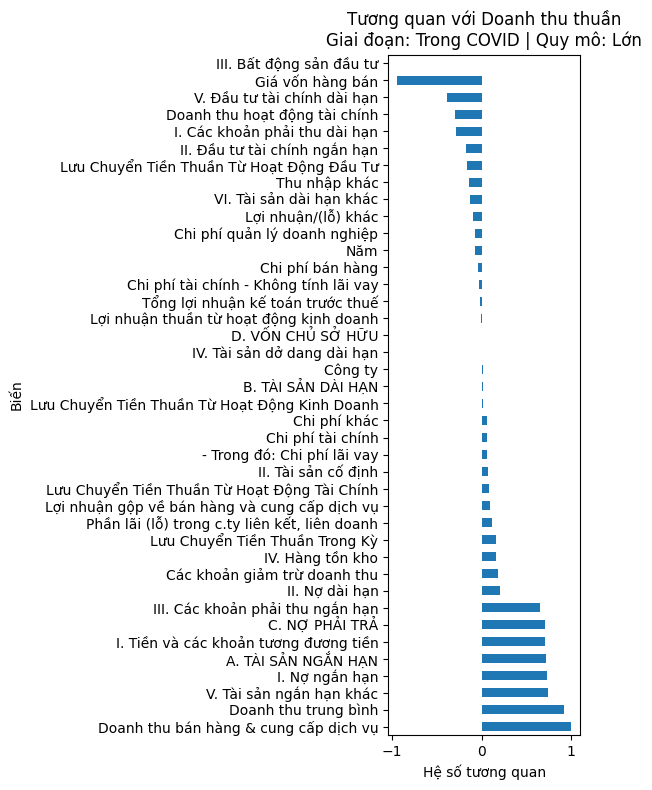

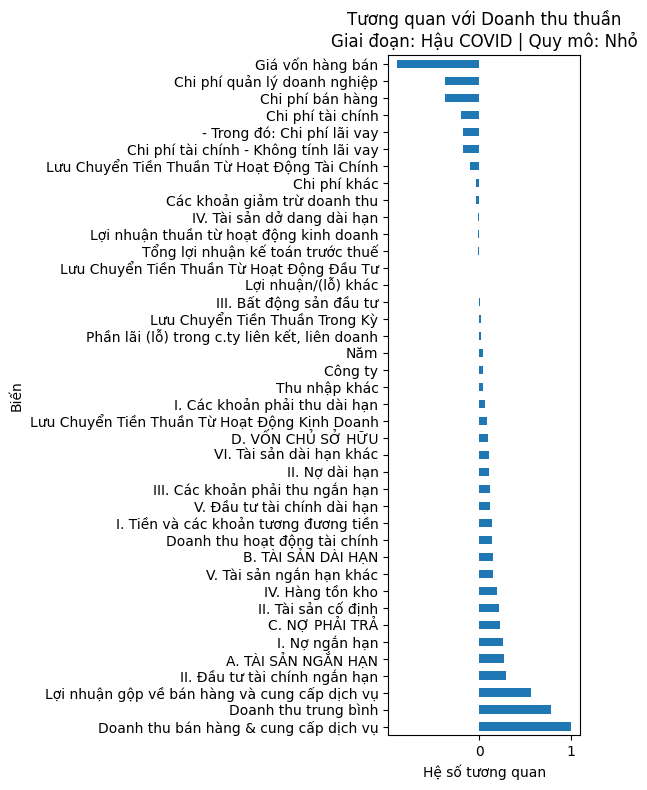

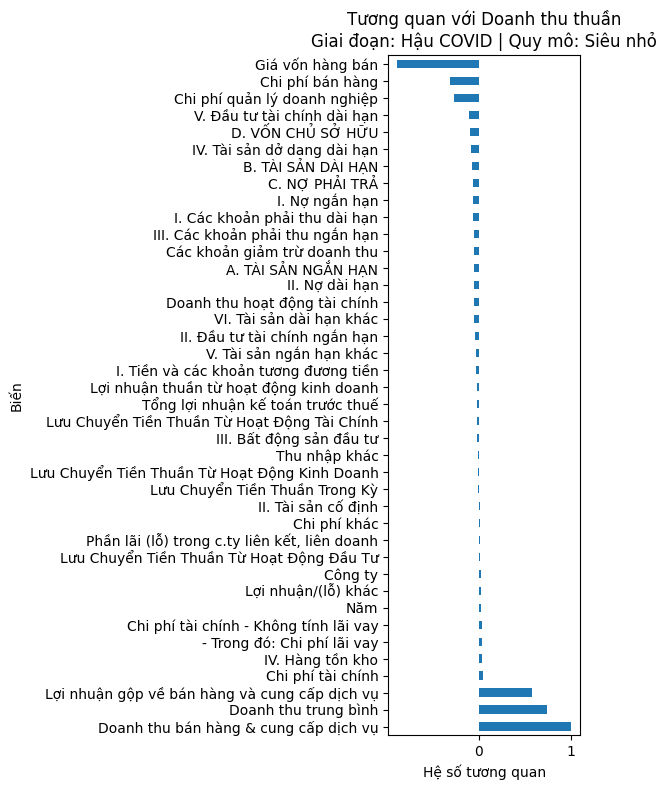

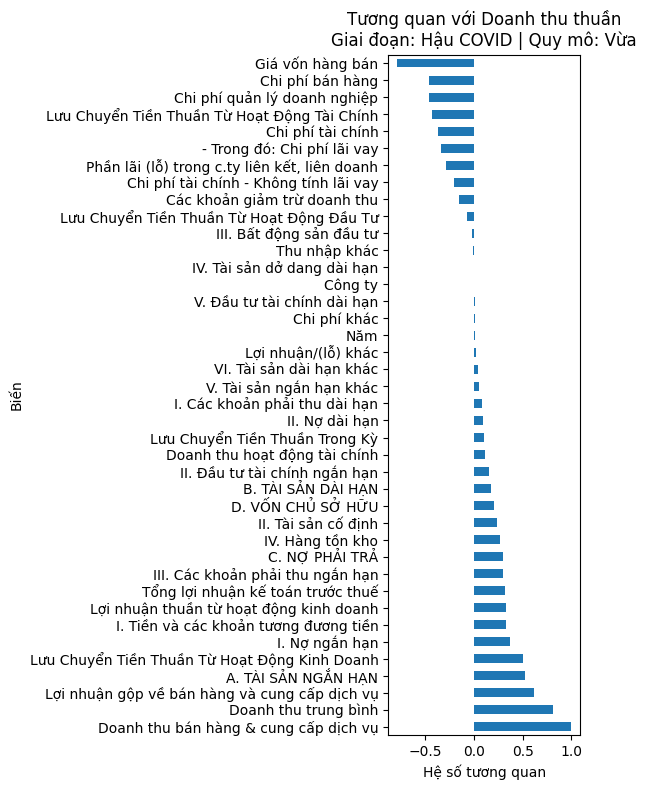

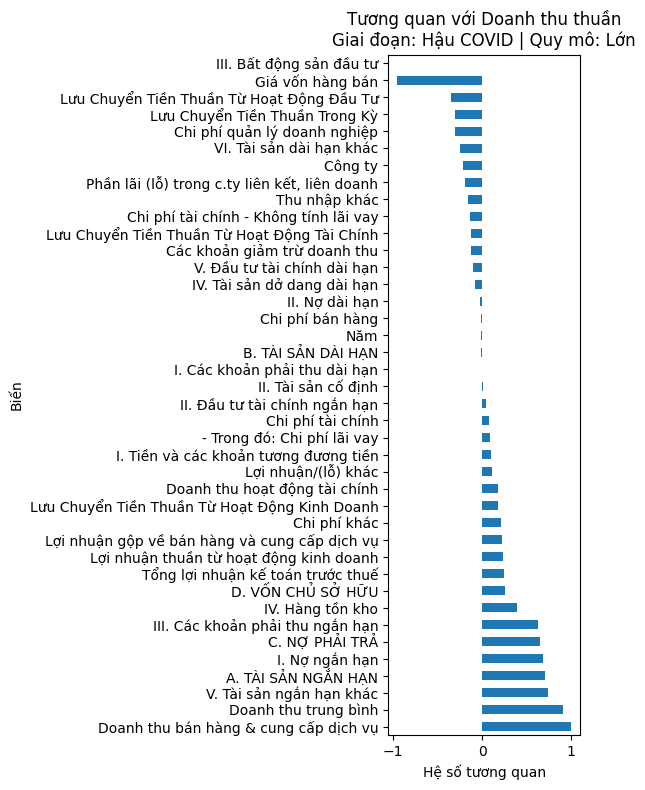

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# B1: Tạo cột GIAI_DOAN
df['GIAI_DOAN'] = df['Năm'].map(
    lambda x: 'Trước COVID' if x == 2019 else
              'Trong COVID' if x in [2020, 2021] else
              'Hậu COVID'
)

# B2: Lấy danh sách các giá trị nhóm quy mô
quy_mos = df['QUY MÔ DOANH NGHIỆP'].dropna().unique()
giai_doans = ['Trước COVID', 'Trong COVID', 'Hậu COVID']

# B3: Loop qua từng giai đoạn và từng quy mô
for giai_doan in giai_doans:
    for quy_mo in quy_mos:
        df_sub = df[(df['GIAI_DOAN'] == giai_doan) & (df['QUY MÔ DOANH NGHIỆP'] == quy_mo)]
        if len(df_sub) < 3:  # Không đủ data sẽ bỏ qua để tránh biểu đồ nhiễu
            continue
        df_numeric = df_sub.select_dtypes(include=np.number)
        corr_matrix = df_numeric.corr()
        if 'Doanh thu thuần bán hàng và cung cấp dịch vụ' in corr_matrix.columns:
            corr_with_rev = corr_matrix['Doanh thu thuần bán hàng và cung cấp dịch vụ'].drop('Doanh thu thuần bán hàng và cung cấp dịch vụ')
            corr_with_rev = corr_with_rev.sort_values(ascending=False)
            plt.figure(figsize=(6, 8))
            corr_with_rev.plot(kind='barh')
            plt.title(f'Tương quan với Doanh thu thuần\nGiai đoạn: {giai_doan} | Quy mô: {quy_mo}')
            plt.xlabel('Hệ số tương quan')
            plt.ylabel('Biến')
            plt.tight_layout()
            plt.show()


In [29]:
import pandas as pd
import numpy as np

# Gán giai đoạn
df['GIAI_DOAN'] = df['Năm'].map(
    lambda x: 'Trước COVID' if x == 2019 else
              'Trong COVID' if x in [2020, 2021] else
              'Hậu COVID'
)

quy_mos = df['QUY MÔ DOANH NGHIỆP'].dropna().unique()
giai_doans = ['Trước COVID', 'Trong COVID', 'Hậu COVID']

for giai_doan in giai_doans:
    for quy_mo in quy_mos:
        df_sub = df[(df['GIAI_DOAN'] == giai_doan) & (df['QUY MÔ DOANH NGHIỆP'] == quy_mo)]
        if len(df_sub) < 3:
            continue
        df_numeric = df_sub.select_dtypes(include=np.number)
        corr_matrix = df_numeric.corr()
        if 'Doanh thu thuần bán hàng và cung cấp dịch vụ' in corr_matrix.columns:
            corr_with_rev = corr_matrix['Doanh thu thuần bán hàng và cung cấp dịch vụ'].drop('Doanh thu thuần bán hàng và cung cấp dịch vụ')
            print(f"\n{giai_doan.upper()} - {str(quy_mo).upper()}")
            print("-" * (len(giai_doan) + len(str(quy_mo)) + 3))
            for var, corr in corr_with_rev.sort_values(ascending=False).items():
                print(f"{var}: {corr:.3f}")



TRƯỚC COVID - NHỎ
-----------------
Doanh thu bán hàng & cung cấp dịch vụ: 0.999
Doanh thu trung bình: 0.727
Lợi nhuận gộp về bán hàng và cung cấp dịch vụ: 0.711
I. Nợ ngắn hạn: 0.456
C. NỢ PHẢI TRẢ: 0.419
II. Tài sản cố định: 0.378
B. TÀI SẢN DÀI HẠN: 0.370
II. Nợ dài hạn: 0.338
VI. Tài sản dài hạn khác: 0.330
III. Các khoản phải thu ngắn hạn: 0.286
V. Tài sản ngắn hạn khác: 0.261
V. Đầu tư tài chính dài hạn: 0.256
A. TÀI SẢN NGẮN HẠN: 0.251
Lưu Chuyển Tiền Thuần Từ Hoạt Động Kinh Doanh: 0.241
IV. Tài sản dở dang dài hạn: 0.228
D. VỐN CHỦ SỞ HỮU: 0.198
IV. Hàng tồn kho: 0.173
I. Các khoản phải thu dài hạn: 0.111
II. Đầu tư tài chính ngắn hạn: 0.085
Doanh thu hoạt động tài chính: 0.077
Phần lãi (lỗ) trong c.ty liên kết, liên doanh: 0.072
Thu nhập khác: 0.051
I. Tiền và các khoản tương đương tiền: 0.048
Lợi nhuận/(lỗ) khác: 0.015
III. Bất động sản đầu tư: -0.013
Công ty: -0.020
Lưu Chuyển Tiền Thuần Từ Hoạt Động Tài Chính: -0.024
Các khoản giảm trừ doanh thu: -0.088
Lưu Chuyển Tiền Thu

# Hồi quy

## Hồi quy tất cả

In [30]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import statsmodels.api as sm

# Chọn biến
cols = [
    'Doanh thu thuần bán hàng và cung cấp dịch vụ',
    # INCOME STATEMENT
    'Giá vốn hàng bán',
    '- Trong đó: Chi phí lãi vay',
    'Chi phí khác',
    'Chi phí bán hàng',
    'Chi phí quản lý doanh nghiệp',
    'Các khoản giảm trừ doanh thu',
    # BALANCE SHEET
    'I. Nợ ngắn hạn',
    'III. Các khoản phải thu ngắn hạn',
    'II. Tài sản cố định',
    'IV. Hàng tồn kho',
    'D. VỐN CHỦ SỞ HỮU',
    'I. Tiền và các khoản tương đương tiền',
    'B. TÀI SẢN DÀI HẠN'
]

# Lọc biến và loại missing
data = df[cols].dropna()

# Tách X, y
y = data['Doanh thu thuần bán hàng và cung cấp dịch vụ']
X = data.drop(columns=['Doanh thu thuần bán hàng và cung cấp dịch vụ'])

# Chuẩn hóa X và y (z-score)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

# Đưa X_scaled vào DataFrame với tên cột gốc để tiện theo dõi
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Thêm constant
X_scaled_sm = sm.add_constant(X_scaled_df)

# Fit mô hình OLS để lấy cả hệ số và p-value (hệ số chuẩn hóa)
model = sm.OLS(y_scaled, X_scaled_sm).fit()
model_params = model.params
model_pvalues = model.pvalues
model_rsquared = model.rsquared

# Lấy hệ số và p-value vào bảng dễ xem
regression_results = pd.DataFrame({
    'Hệ số chuẩn hóa (Std Coef.)': model_params,
    'P-value': model_pvalues
})

print(regression_results)
print("R-squared:", model_rsquared)


                                       Hệ số chuẩn hóa (Std Coef.)  \
const                                                 7.968872e-18   
Giá vốn hàng bán                                     -8.606743e-01   
- Trong đó: Chi phí lãi vay                           1.901578e-03   
Chi phí khác                                          2.123526e-02   
Chi phí bán hàng                                     -2.466977e-01   
Chi phí quản lý doanh nghiệp                         -8.599007e-02   
Các khoản giảm trừ doanh thu                          3.332538e-02   
I. Nợ ngắn hạn                                       -5.564453e-03   
III. Các khoản phải thu ngắn hạn                     -1.354325e-02   
II. Tài sản cố định                                   4.716604e-03   
IV. Hàng tồn kho                                     -7.966242e-03   
D. VỐN CHỦ SỞ HỮU                                     1.196154e-02   
I. Tiền và các khoản tương đương tiền                 1.664998e-02   
B. TÀI SẢN DÀI HẠN  

## Hồi quy theo quy mô

In [31]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import statsmodels.api as sm

# Chọn biến
cols = [
    'Doanh thu thuần bán hàng và cung cấp dịch vụ',
    # INCOME STATEMENT
    'Giá vốn hàng bán',
    '- Trong đó: Chi phí lãi vay',
    'Chi phí khác',
    'Chi phí bán hàng',
    'Chi phí quản lý doanh nghiệp',
    'Các khoản giảm trừ doanh thu',
    # BALANCE SHEET
    'I. Nợ ngắn hạn',
    'A. TÀI SẢN NGẮN HẠN',
    'III. Các khoản phải thu ngắn hạn',
    'II. Tài sản cố định',
    'IV. Hàng tồn kho',
    'D. VỐN CHỦ SỞ HỮU',
    'I. Tiền và các khoản tương đương tiền',
    'B. TÀI SẢN DÀI HẠN',

    'QUY MÔ DOANH NGHIỆP'
]

# Lọc dữ liệu và loại missing
data = df[cols].dropna()

# Lấy các nhóm quy mô
scales = data['QUY MÔ DOANH NGHIỆP'].unique()

regression_dict = {}

for scale in scales:
    sub = data[data['QUY MÔ DOANH NGHIỆP'] == scale]
    X = sub.drop(columns=['Doanh thu thuần bán hàng và cung cấp dịch vụ', 'QUY MÔ DOANH NGHIỆP'])
    y = sub['Doanh thu thuần bán hàng và cung cấp dịch vụ']

    # Chuẩn hóa
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
    X_scaled_sm = sm.add_constant(X_scaled_df)

    model = sm.OLS(y_scaled, X_scaled_sm).fit()
    result = pd.DataFrame({
        'Hệ số chuẩn hóa (Std Coef.)': model.params,
        'P-value': model.pvalues
    })
    regression_dict[scale] = (result, model.rsquared)

# In kết quả cho từng quy mô
for scale in regression_dict:
    print(f"\n===== {scale} =====")
    print(regression_dict[scale][0])
    print("R-squared:", regression_dict[scale][1])



===== Nhỏ =====
                                       Hệ số chuẩn hóa (Std Coef.)  \
const                                                -1.821460e-17   
Giá vốn hàng bán                                     -8.566208e-01   
- Trong đó: Chi phí lãi vay                           5.496319e-02   
Chi phí khác                                          1.883555e-03   
Chi phí bán hàng                                     -2.494741e-01   
Chi phí quản lý doanh nghiệp                         -8.361814e-02   
Các khoản giảm trừ doanh thu                          7.495326e-03   
I. Nợ ngắn hạn                                        8.600314e-02   
A. TÀI SẢN NGẮN HẠN                                  -1.628507e-03   
III. Các khoản phải thu ngắn hạn                     -3.920926e-02   
II. Tài sản cố định                                  -3.874129e-02   
IV. Hàng tồn kho                                      1.122657e-02   
D. VỐN CHỦ SỞ HỮU                                     2.715336e-02   
I. 

## Hồi quy theo giai đoạn

## Hồi quy theo quy mô và giai đoạn

In [32]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import statsmodels.api as sm

# Chọn biến

cols = [
    # ĐẶC TRƯNG DOANH NGHIỆP
    'Doanh thu thuần bán hàng và cung cấp dịch vụ',
    'Năm',
    'QUY MÔ DOANH NGHIỆP',

    # INCOME STATEMENT
    'Giá vốn hàng bán',
    'Chi phí tài chính',
    'Chi phí bán hàng',
    'Chi phí quản lý doanh nghiệp',
    'Chi phí khác',
    'Các khoản giảm trừ doanh thu',

    # BALANCE SHEET
    'D. VỐN CHỦ SỞ HỮU',
    'B. TÀI SẢN DÀI HẠN',
    'I. Nợ ngắn hạn',
    'II. Nợ dài hạn',
    'III. Các khoản phải thu ngắn hạn',
    'IV. Hàng tồn kho',
    'I. Tiền và các khoản tương đương tiền',

    # # CASH FLOW
    # 'Lưu Chuyển Tiền Thuần Từ Hoạt Động Kinh Doanh',
    # 'Lưu Chuyển Tiền Thuần Từ Hoạt Động Đầu Tư',
    # 'Lưu Chuyển Tiền Thuần Từ Hoạt Động Tài Chính'
]




# Lọc dữ liệu và loại missing
data = df[cols].dropna()

# Giai đoạn định nghĩa
periods = {
    "Trước COVID": [2019],
    "COVID": [2020, 2021],
    "Hậu COVID": [2022, 2023]
}

regression_dict = {}

for pname, years in periods.items():
    data_period = data[data['Năm'].isin(years)]
    scales = data_period['QUY MÔ DOANH NGHIỆP'].unique()
    for scale in scales:
        sub = data_period[data_period['QUY MÔ DOANH NGHIỆP'] == scale]
        if sub.shape[0] < 15:  # Bỏ qua nếu nhóm quá ít mẫu
            continue
        X = sub.drop(columns=['Doanh thu thuần bán hàng và cung cấp dịch vụ', 'QUY MÔ DOANH NGHIỆP', 'Năm'])
        y = sub['Doanh thu thuần bán hàng và cung cấp dịch vụ']

        # Chuẩn hóa
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X_scaled = scaler_X.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

        X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
        X_scaled_sm = sm.add_constant(X_scaled_df)

        model = sm.OLS(y_scaled, X_scaled_sm).fit()
        result = pd.DataFrame({
            'Hệ số chuẩn hóa (Std Coef.)': model.params,
            'P-value': model.pvalues
        })
        regression_dict[(pname, scale)] = (result, model.rsquared)

# In kết quả cho từng quy mô & giai đoạn
for key in regression_dict:
    pname, scale = key
    print(f"\n===== {scale} | {pname} =====")
    print(regression_dict[key][0])
    print("R-squared:", regression_dict[key][1])



===== Nhỏ | Trước COVID =====
                                       Hệ số chuẩn hóa (Std Coef.)  \
const                                                -5.919089e-17   
Giá vốn hàng bán                                     -8.410098e-01   
Chi phí tài chính                                    -2.289814e-02   
Chi phí bán hàng                                     -2.483402e-01   
Chi phí quản lý doanh nghiệp                         -1.728733e-01   
Chi phí khác                                          3.836028e-02   
Các khoản giảm trừ doanh thu                          7.453954e-03   
D. VỐN CHỦ SỞ HỮU                                    -2.667711e-01   
B. TÀI SẢN DÀI HẠN                                    4.029205e-01   
I. Nợ ngắn hạn                                       -1.897444e-01   
II. Nợ dài hạn                                       -1.902216e-01   
III. Các khoản phải thu ngắn hạn                      1.371062e-01   
IV. Hàng tồn kho                                     -5.096

In [33]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import statsmodels.api as sm

# Chọn biến
cols = [
    'Doanh thu thuần bán hàng và cung cấp dịch vụ',
    'Năm',
    'Công ty',
    # INCOME STATEMENT
    'Giá vốn hàng bán',
    '- Trong đó: Chi phí lãi vay',
    'Chi phí khác',
    'Chi phí bán hàng',
    'Chi phí quản lý doanh nghiệp',
    'Các khoản giảm trừ doanh thu',
    # BALANCE SHEET
    'I. Nợ ngắn hạn',
    'A. TÀI SẢN NGẮN HẠN',
    'III. Các khoản phải thu ngắn hạn',
    'II. Tài sản cố định',
    'IV. Hàng tồn kho',
    'D. VỐN CHỦ SỞ HỮU',
    'I. Tiền và các khoản tương đương tiền',
    'B. TÀI SẢN DÀI HẠN',
    'QUY MÔ DOANH NGHIỆP'
]

# Lọc dữ liệu và loại missing
data = df[cols].dropna()

# Giai đoạn định nghĩa
periods = {
    "Trước COVID": [2019],
    "COVID": [2020, 2021],
    "Hậu COVID": [2022, 2023]
}

regression_dict = {}

for pname, years in periods.items():
    data_period = data[data['Năm'].isin(years)]
    scales = data_period['QUY MÔ DOANH NGHIỆP'].unique()
    for scale in scales:
        sub = data_period[data_period['QUY MÔ DOANH NGHIỆP'] == scale]
        if sub.shape[0] < 15:  # Bỏ qua nếu nhóm quá ít mẫu
            continue
        X = sub.drop(columns=['Doanh thu thuần bán hàng và cung cấp dịch vụ', 'QUY MÔ DOANH NGHIỆP', 'Năm', 'Công ty'])
        y = sub['Doanh thu thuần bán hàng và cung cấp dịch vụ']

        # Chuẩn hóa
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X_scaled = scaler_X.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

        X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
        X_scaled_sm = sm.add_constant(X_scaled_df)

        model = sm.OLS(y_scaled, X_scaled_sm).fit()
        result = pd.DataFrame({
            'Hệ số chuẩn hóa (Std Coef.)': model.params,
            'P-value': model.pvalues
        })

        # Lưu cả object model vào dict để dùng dự báo/predict về sau
        regression_dict[(pname, scale)] = (result, model, model.rsquared)

# In kết quả cho từng quy mô & giai đoạn
for key in regression_dict:
    pname, scale = key
    print(f"\n===== {scale} | {pname} =====")
    print(regression_dict[key][0])
    print("R-squared:", regression_dict[key][2])  # đổi sang [2] vì [1] bây giờ là model object



===== Nhỏ | Trước COVID =====
                                       Hệ số chuẩn hóa (Std Coef.)  \
const                                                -3.170620e-17   
Giá vốn hàng bán                                     -8.384348e-01   
- Trong đó: Chi phí lãi vay                           6.216267e-03   
Chi phí khác                                          2.388814e-02   
Chi phí bán hàng                                     -2.492909e-01   
Chi phí quản lý doanh nghiệp                         -1.775708e-01   
Các khoản giảm trừ doanh thu                          8.092696e-03   
I. Nợ ngắn hạn                                       -9.288417e-02   
A. TÀI SẢN NGẮN HẠN                                  -1.423880e-01   
III. Các khoản phải thu ngắn hạn                      1.345183e-01   
II. Tài sản cố định                                   1.828899e-02   
IV. Hàng tồn kho                                     -7.380487e-03   
D. VỐN CHỦ SỞ HỮU                                    -6.423

# Chia nhóm doanh nghiệp

## Các loại doanh nghiệp khác

In [34]:
# Đếm số doanh nghiệp có đủ doanh thu cho cả 2019, 2021, 2023
company_years = df.pivot(index='Công ty', columns='Năm', values='Doanh thu thuần bán hàng và cung cấp dịch vụ')
print(company_years.notnull().sum(axis=1).value_counts())

# Xem những công ty thiếu năm nào
missing = company_years[company_years.isnull().any(axis=1)]
print(missing)


5    1594
Name: count, dtype: int64
Empty DataFrame
Columns: [2019, 2020, 2021, 2022, 2023]
Index: []


In [35]:
company_years = df.pivot(index='Công ty', columns='Năm', values='Doanh thu thuần bán hàng và cung cấp dịch vụ')
print((company_years == 0).sum())  # Tổng số doanh nghiệp có doanh thu bằng 0 mỗi năm


Năm
2019    210
2020    181
2021    227
2022    228
2023    245
dtype: int64


In [36]:
for year in [2019, 2021, 2023]:
    print(f"Công ty có doanh thu 0 năm {year}:")
    print(company_years[company_years[year]==0].index.tolist())


Công ty có doanh thu 0 năm 2019:
[7, 14, 17, 18, 19, 26, 27, 33, 36, 45, 47, 55, 56, 58, 61, 63, 69, 78, 80, 81, 98, 117, 127, 131, 137, 154, 156, 182, 191, 208, 225, 231, 236, 239, 245, 270, 271, 278, 283, 316, 330, 337, 357, 363, 365, 383, 384, 390, 402, 403, 407, 429, 438, 461, 469, 480, 487, 490, 497, 510, 512, 513, 515, 517, 533, 539, 542, 549, 550, 560, 563, 567, 570, 578, 581, 584, 590, 594, 597, 603, 604, 607, 611, 616, 618, 642, 652, 661, 663, 669, 692, 695, 701, 705, 719, 721, 727, 730, 734, 737, 743, 760, 771, 775, 783, 784, 795, 804, 811, 829, 833, 853, 854, 857, 869, 873, 876, 888, 897, 899, 927, 961, 972, 990, 993, 1006, 1009, 1024, 1034, 1036, 1046, 1049, 1057, 1061, 1074, 1075, 1078, 1083, 1096, 1105, 1107, 1112, 1123, 1134, 1139, 1145, 1146, 1147, 1162, 1163, 1164, 1175, 1184, 1186, 1198, 1201, 1212, 1231, 1236, 1239, 1241, 1242, 1257, 1264, 1265, 1266, 1285, 1293, 1308, 1318, 1331, 1338, 1344, 1353, 1355, 1356, 1362, 1367, 1374, 1377, 1383, 1389, 1395, 1396, 1401, 142

In [37]:
years_needed = [2019, 2021, 2023]

# Tạo bảng pivot doanh thu từng năm
company_years = df.pivot(index='Công ty', columns='Năm', values='Doanh thu thuần bán hàng và cung cấp dịch vụ')

# Loại bỏ doanh nghiệp có NaN ở các năm cần thiết
company_years_valid = company_years.dropna(subset=years_needed)

# Tiếp tục loại những doanh nghiệp có doanh thu = 0 ở bất kỳ năm nào trong years_needed
for year in years_needed:
    company_years_valid = company_years_valid[company_years_valid[year] > 0]

# Kết quả
print(f"Số doanh nghiệp đủ dữ liệu và doanh thu dương ở các năm {years_needed}: {company_years_valid.shape[0]}")
print(f"Số doanh nghiệp bị loại bỏ: {company_years.shape[0] - company_years_valid.shape[0]}")


Số doanh nghiệp đủ dữ liệu và doanh thu dương ở các năm [2019, 2021, 2023]: 1228
Số doanh nghiệp bị loại bỏ: 366


In [38]:
def company_status(row):
    vals = row[years_needed].values
    if np.all(vals > 0):
        return "Hoạt động liên tục"
    elif np.all(vals == 0):
        return "Không hoạt động"
    elif (vals[0] == 0) and np.any(vals[1:] > 0):
        return "Mới hồi sinh/Startup"
    elif (vals[-1] == 0) and np.any(vals[:-1] > 0):
        return "Rời khỏi thị trường"
    else:
        return "Bị gián đoạn (up & down)"

company_years['Trạng thái DN'] = company_years.apply(company_status, axis=1)
print(company_years['Trạng thái DN'].value_counts())


Trạng thái DN
Hoạt động liên tục          1228
Không hoạt động              119
Rời khỏi thị trường          117
Mới hồi sinh/Startup          91
Bị gián đoạn (up & down)      39
Name: count, dtype: int64


In [39]:
# Giả sử company_years là bảng pivot doanh thu như bạn đã tạo
bi_gian_doan = company_years[
    (company_years[2019] > 0) &
    (company_years[2021] == 0) &
    (company_years[2022] > 0)
]

print(f"Số DN gián đoạn đúng logic: {bi_gian_doan.shape[0]}")
print(bi_gian_doan[[2019, 2021, 2023]])


Số DN gián đoạn đúng logic: 31
Năm              2019  2021          2023
Công ty                                  
132      5.055000e+06   0.0  1.000000e+07
141      4.717223e+08   0.0  1.162210e+07
166      1.596381e+09   0.0  1.940968e+09
215      1.131750e+08   0.0  3.036873e+07
288      1.227273e+08   0.0  2.615726e+09
311      1.883818e+08   0.0  0.000000e+00
377      2.932046e+08   0.0  3.718615e+08
387      2.311293e+08   0.0  0.000000e+00
441      2.432326e+09   0.0  0.000000e+00
446      2.540560e+08   0.0  0.000000e+00
493      2.061414e+09   0.0  5.228658e+08
554      3.940304e+08   0.0  7.398632e+08
649      3.606227e+08   0.0  1.138997e+09
653      2.228211e+08   0.0  3.231900e+09
682      2.939674e+09   0.0  7.356364e+08
718      4.439982e+09   0.0  1.917831e+09
772      1.701481e+09   0.0  8.489765e+08
969      8.563880e+08   0.0  0.000000e+00
973      1.921349e+09   0.0  4.131065e+09
1168     6.819909e+07   0.0  3.424455e+08
1191     2.134602e+09   0.0  1.818385e+09
119

## Cũ

In [40]:
# --- Đặt tên cột ID doanh nghiệp ---
ID_COL = 'Công ty'  # Sửa lại tên nếu file bạn khác

# 1. Tạo list chứa dự báo và phần dư cho từng DN từng năm
preds_list = []

for pname, years in periods.items():
    data_period = data[data['Năm'].isin(years)]
    for scale in data_period['QUY MÔ DOANH NGHIỆP'].unique():
        sub = data_period[data_period['QUY MÔ DOANH NGHIỆP'] == scale].copy()
        if sub.shape[0] < 15:
            continue

        # Lấy model đã lưu
        result, model_obj, model_rsq = regression_dict.get((pname, scale), (None, None, None))
        if result is None or model_obj is None:
            continue

        # Chuẩn hóa lại như lúc train
        X = sub.drop(columns=['Doanh thu thuần bán hàng và cung cấp dịch vụ', 'QUY MÔ DOANH NGHIỆP', 'Năm', 'Công ty'])
        y = sub['Doanh thu thuần bán hàng và cung cấp dịch vụ']
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X_scaled = scaler_X.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

        X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
        X_scaled_sm = sm.add_constant(X_scaled_df)

        # Dự báo doanh thu chuẩn hóa
        y_pred = model_obj.predict(X_scaled_sm)

        sub[ID_COL] = sub[ID_COL].values  # Đảm bảo tồn tại cột ID
        sub['Năm'] = sub['Năm'].values
        sub['Doanh thu thực tế chuẩn hóa'] = y_scaled
        sub['Doanh thu dự báo chuẩn hóa'] = y_pred
        sub['Residual'] = y_scaled - y_pred

        preds_list.append(sub[[ID_COL, 'Năm', 'Doanh thu thực tế chuẩn hóa', 'Doanh thu dự báo chuẩn hóa', 'Residual', 'Doanh thu thuần bán hàng và cung cấp dịch vụ', 'QUY MÔ DOANH NGHIỆP']])

# 2. Gộp lại thành DataFrame lớn cho toàn bộ các năm
preds_df = pd.concat(preds_list, ignore_index=True)

# 3. Pivot doanh thu thực tế theo năm để tính growth cho từng DN
pivot = preds_df.pivot(index=ID_COL, columns='Năm', values='Doanh thu thuần bán hàng và cung cấp dịch vụ')

# 4. Tính các chỉ số tăng trưởng
pivot['Growth_2019_2021'] = (pivot[2021] - pivot[2019]) / pivot[2019]
pivot['Growth_2021_2023'] = (pivot[2023] - pivot[2021]) / pivot[2021]
pivot['Growth_2019_2023'] = (pivot[2023] - pivot[2019]) / pivot[2019]

# >>> THÊM ĐOẠN NÀY <<<
median_growth_21_23 = pivot['Growth_2021_2023'].median()
pivot['Phuc_hoi_tot'] = pivot['Growth_2021_2023'] > median_growth_21_23
# <<< HẾT >>>

# 5. Tính chỉ số bền vững (growth từng đoạn đều dương)
pivot['Sustainable_hau_covid'] = (
    (pivot[2022] > pivot[2021]) &
    (pivot[2023] > pivot[2022])
)

# 6. Lấy phần dư trung bình hậu COVID (năm 2023)
mean_residual = preds_df[preds_df['Năm'] == 2023].groupby(ID_COL)['Residual'].mean()
pivot = pivot.join(mean_residual.rename('Mean_Residual_2023'))

# 7. Đánh giá hiệu quả bán hàng
growth_median = pivot['Growth_2019_2023'].median()
pivot['Sales_Efficiency'] = np.where(
    (pivot['Mean_Residual_2023'] > 0) & (pivot['Growth_2019_2023'] > growth_median),
    'High', 'Low'
)

# 8. Phân nhóm theo ma trận hiệu quả & bền vững
def assign_group(row):
    if row['Sales_Efficiency'] == 'High' and row['Sustainable_hau_covid']:
        return 'Nhóm 1 (Mở rộng quy mô)'
    elif row['Sales_Efficiency'] == 'High' and not row['Sustainable_hau_covid']:
        return 'Nhóm 2 (Ổn định quy trình)'
    elif row['Sales_Efficiency'] == 'Low' and row['Sustainable_hau_covid']:
        return 'Nhóm 3 (Tối ưu mô hình KD)'
    else:
        return 'Nhóm 4 (Cần hỗ trợ mạnh)'

pivot['Group'] = pivot.apply(assign_group, axis=1)

# 9. Xuất bảng kết quả
pivot_reset = pivot.reset_index()
print(pivot_reset[[ID_COL, 'Growth_2019_2021', 'Growth_2021_2023', 'Growth_2019_2023', 'Sustainable_hau_covid', 'Mean_Residual_2023', 'Sales_Efficiency', 'Group']].head(20))

# Nếu muốn lưu file:
# pivot_reset.to_excel('phan_nhom_doanh_nghiep_FnB.xlsx', index=False)


    Công ty  Growth_2019_2021  Growth_2021_2023  Growth_2019_2023  \
0         2         -0.441252          0.191879         -0.334040   
1         3         -0.967529         25.715786         -0.132516   
2         6          3.286653         -0.310076          1.957465   
3         7               NaN               NaN               NaN   
4         8               NaN               NaN               NaN   
5         9               NaN               NaN               NaN   
6        10         -0.532890         -0.129226         -0.593253   
7        12          0.359124          1.630249          2.574833   
8        13         -0.556767          1.148007         -0.047932   
9        14               NaN               NaN               NaN   
10       15          3.599239          0.103089          4.073369   
11       17               NaN               inf               NaN   
12       19               NaN               NaN               NaN   
13       20         -0.661768     

## Mới

In [41]:
# 0. Lọc doanh nghiệp hoạt động liên tục 2021–2023 (không bị gián đoạn, không phải startup)
pivot_active = pivot[(pivot[2021] > 0) & (pivot[2022] > 0) & (pivot[2023] > 0)].copy()

# 1. Tính tăng trưởng hậu COVID cho từng công ty
pivot_active['Growth_2021_2023'] = (pivot_active[2023] - pivot_active[2021]) / pivot_active[2021]

# 2. Tính trung vị tăng trưởng hậu COVID cho từng quy mô ngành
growth_median_by_scale = pivot_active.groupby('QUY MÔ DOANH NGHIỆP')['Growth_2021_2023'].transform('mean')

# 3. Đánh dấu doanh nghiệp phục hồi tốt nếu tăng trưởng > trung vị nhóm quy mô của nó
pivot_active['Phuc_hoi_tot'] = pivot_active['Growth_2021_2023'] > growth_median_by_scale

# 4. Đánh giá bền vững hậu COVID: Doanh thu tăng đều 2021 → 2022 → 2023
pivot_active['Sustainable_hau_covid'] = (
    (pivot_active[2022] >= pivot_active[2021]) &
    (pivot_active[2023] >= pivot_active[2022])
)

# 5. Chia nhóm 4 theo 2 tiêu chí trên
def assign_group(row):
    if row['Phuc_hoi_tot'] and row['Sustainable_hau_covid']:
        return 'Nhóm 1 (Mở rộng quy mô)'
    elif row['Phuc_hoi_tot'] and not row['Sustainable_hau_covid']:
        return 'Nhóm 2 (Ổn định quy trình)'
    elif (not row['Phuc_hoi_tot']) and row['Sustainable_hau_covid']:
        return 'Nhóm 3 (Tối ưu mô hình KD)'
    else:
        return 'Nhóm 4 (Cần hỗ trợ mạnh)'

pivot_active['Group'] = pivot_active.apply(assign_group, axis=1)

# 6. Xuất bảng kết quả
pivot_reset = pivot_active.reset_index()
print(pivot_reset[[ID_COL, 'QUY MÔ DOANH NGHIỆP', 2021, 2022, 2023,
                   'Growth_2021_2023', 'Phuc_hoi_tot', 'Sustainable_hau_covid', 'Group']].head(20))

# Nếu muốn lưu ra file:
# pivot_reset.to_excel('phan_nhom_dn_active_FnB_final.xlsx', index=False)


KeyError: 'QUY MÔ DOANH NGHIỆP'

In [ ]:
bentu_hau_covid = pivot_reset[pivot_reset['Sustainable_hau_covid'] == True]
print(bentu_hau_covid[['Công ty', 2021, 2022, 2023]])


In [ ]:
pivot_reset['Group'].value_counts()

In [ ]:
pivot_reset.to_excel('phan_nhom_doanh_nghiep_FnB.xlsx', index=False)
